In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)

100%|██████████| 1.26G/1.26G [00:14<00:00, 95.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


In [ ]:
# Buscar el archivo CSV dentro de todas las subcarpetas
ruta = None

for carpeta_raiz, subcarpetas, archivos in os.walk(path):
    for archivo in archivos:
        if "accepted" in archivo.lower() and archivo.endswith(".csv"):
            ruta = os.path.join(carpeta_raiz, archivo)
            print(f"Archivo encontrado: {ruta}")
            break
    if ruta:
        break

if ruta is None:
    # Si no encuentra nada, muestra toda la estructura para ver qué hay
    print("No se encontró el archivo. Estructura de carpetas:")
    for carpeta_raiz, subcarpetas, archivos in os.walk(path):
        print(f"\nCarpeta: {carpeta_raiz}")
        for archivo in archivos:
            print(f"   - {archivo}")
    raise FileNotFoundError("No se encontró ningún archivo CSV de aceptados.")

print("\nCargando dataset... (puede tardar unos minutos por el tamaño)")
df = pd.read_csv(ruta, low_memory=False)

print(f"\n Dataset cargado correctamente.")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]:,}")

Archivo encontrado: /root/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv

Cargando dataset... (puede tardar unos minutos por el tamaño)

 Dataset cargado correctamente.
   Filas    : 2,260,701
   Columnas : 151


In [ ]:
# PARTE 2: EXPLORACIÓN INICIAL

print("=" * 60)
print("VISTA GENERAL DEL DATASET")
print("=" * 60)

# Primeras filas
print("\n--- Primeras 5 filas ---")
print(df.head())

# Información general
print("\n--- Información general ---")
df.info(verbose=False, show_counts=True)

# Estadísticas descriptivas
print("\n--- Estadísticas descriptivas ---")
print(df.describe())

# Tipos de datos
print("\n--- Tipos de datos por columna ---")
print(df.dtypes.value_counts())

VISTA GENERAL DEL DATASET

--- Primeras 5 filas ---
         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...                            

In [ ]:
# PARTE 3: ANÁLISIS DE VALORES NULOS

print("=" * 60)
print("ANÁLISIS DE VALORES NULOS")
print("=" * 60)

total_filas = len(df)

nulos = df.isnull().sum()
porcentaje_nulos = (nulos / total_filas) * 100

resumen_nulos = pd.DataFrame({
    'Valores_Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos
}).sort_values('Porcentaje (%)', ascending=False)

resumen_nulos = resumen_nulos[resumen_nulos['Valores_Nulos'] > 0]

print(f"\nColumnas con valores nulos: {len(resumen_nulos)}")
print("\nTop 20 columnas con más nulos:")
print(resumen_nulos.head(20).to_string())

col_alta  = resumen_nulos[resumen_nulos['Porcentaje (%)'] > 50].index.tolist()
col_media = resumen_nulos[(resumen_nulos['Porcentaje (%)'] > 5) &
                           (resumen_nulos['Porcentaje (%)'] <= 50)].index.tolist()
col_baja  = resumen_nulos[resumen_nulos['Porcentaje (%)'] <= 5].index.tolist()

print(f"\n Columnas con >50% nulos  (se eliminarán) : {len(col_alta)}")
print(f" Columnas con 5-50% nulos (se imputarán)  : {len(col_media)}")
print(f" Columnas con <5%  nulos  (se imputarán)  : {len(col_baja)}")

ANÁLISIS DE VALORES NULOS

Columnas con valores nulos: 150

Top 20 columnas con más nulos:
                                            Valores_Nulos  Porcentaje (%)
member_id                                         2260701      100.000000
orig_projected_additional_accrued_interest        2252050       99.617331
hardship_reason                                   2249784       99.517097
hardship_payoff_balance_amount                    2249784       99.517097
hardship_last_payment_amount                      2249784       99.517097
payment_plan_start_date                           2249784       99.517097
hardship_type                                     2249784       99.517097
hardship_status                                   2249784       99.517097
hardship_start_date                               2249784       99.517097
deferral_term                                     2249784       99.517097
hardship_amount                                   2249784       99.517097
hardship_dpd         

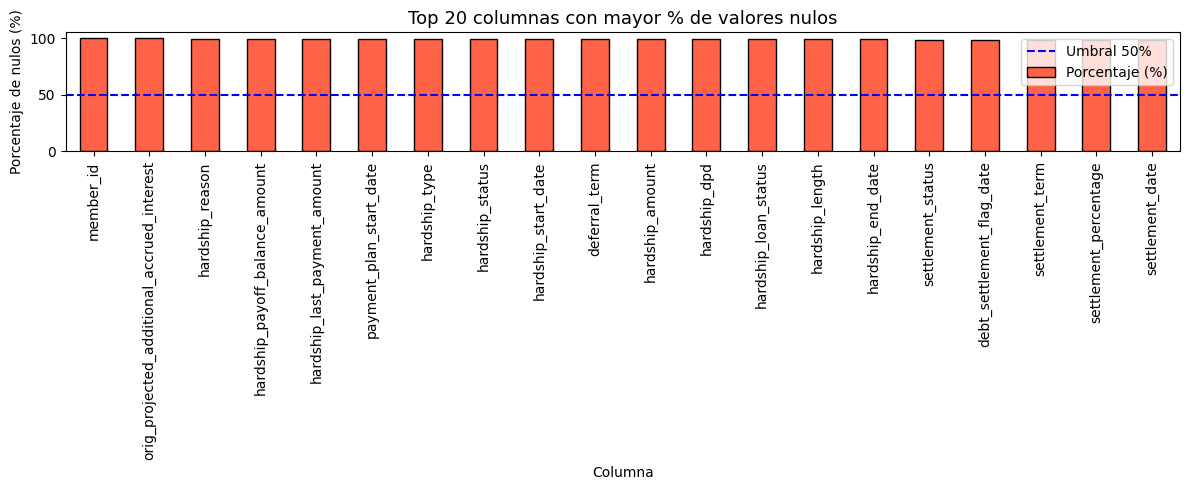

In [ ]:
# Gráfico de barras
plt.figure(figsize=(12, 5))
resumen_nulos.head(20)['Porcentaje (%)'].plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Top 20 columnas con mayor % de valores nulos', fontsize=13)
plt.ylabel('Porcentaje de nulos (%)')
plt.xlabel('Columna')
plt.axhline(y=50, color='blue', linestyle='--', label='Umbral 50%')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# PARTE 4: TRATAMIENTO DE VALORES NULOS

print("=" * 60)
print("TRATAMIENTO DE VALORES NULOS")
print("=" * 60)

df_limpio = df.copy()
cols_antes = df_limpio.shape[1]

# Eliminar columnas con más del 50% de nulos
print(f"\n  Eliminando {len(col_alta)} columnas con >50% de nulos...")
df_limpio.drop(columns=col_alta, inplace=True)
print(f"   Columnas restantes: {df_limpio.shape[1]} (antes: {cols_antes})")

# Imputar columnas con nulos moderados (5-50%)
print("\n Imputando columnas con 5-50% de nulos...")
for col in col_media:
    if col not in df_limpio.columns:
        continue
    if df_limpio[col].dtype == 'object':
        moda = df_limpio[col].mode()
        if not moda.empty:
            df_limpio[col].fillna(moda[0], inplace=True)
    else:
        df_limpio[col].fillna(df_limpio[col].median(), inplace=True)

# Imputar columnas con pocos nulos (<5%)
print("\n Imputando columnas con <5% de nulos...")
for col in col_baja:
    if col not in df_limpio.columns:
        continue
    if df_limpio[col].dtype == 'object':
        moda = df_limpio[col].mode()
        if not moda.empty:
            df_limpio[col].fillna(moda[0], inplace=True)
    else:
        df_limpio[col].fillna(df_limpio[col].median(), inplace=True)

nulos_restantes = df_limpio.isnull().sum().sum()
print(f"\n Valores nulos restantes: {nulos_restantes:,}")

TRATAMIENTO DE VALORES NULOS

  Eliminando 44 columnas con >50% de nulos...
   Columnas restantes: 107 (antes: 151)

 Imputando columnas con 5-50% de nulos...


/tmp/ipykernel_1937/1769795888.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_limpio[col].fillna(df_limpio[col].median(), inplace=True)
/tmp/ipykernel_1937/1769795888.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac


 Imputando columnas con <5% de nulos...


/tmp/ipykernel_1937/1769795888.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_limpio[col].fillna(df_limpio[col].median(), inplace=True)
/tmp/ipykernel_1937/1769795888.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac


 Valores nulos restantes: 0


In [ ]:
# PARTE 5: DETECCIÓN Y ELIMINACIÓN DE DUPLICADOS


print("=" * 60)
print("TRATAMIENTO DE REGISTROS DUPLICADOS")
print("=" * 60)

filas_antes = len(df_limpio)

duplicados_exactos = df_limpio.duplicated().sum()
print(f"\n Filas completamente duplicadas: {duplicados_exactos:,}")

if 'id' in df_limpio.columns:
    duplicados_id = df_limpio.duplicated(subset=['id']).sum()
    print(f" Filas con 'id' duplicado: {duplicados_id:,}")

df_limpio.drop_duplicates(inplace=True)
df_limpio.reset_index(drop=True, inplace=True)

filas_despues = len(df_limpio)
print(f"\n  Filas eliminadas: {filas_antes - filas_despues:,}")
print(f"   Filas antes  : {filas_antes:,}")
print(f"   Filas después: {filas_despues:,}")
print(f"\n Duplicados restantes: {df_limpio.duplicated().sum():,}")

TRATAMIENTO DE REGISTROS DUPLICADOS

 Filas completamente duplicadas: 0
 Filas con 'id' duplicado: 0

  Filas eliminadas: 0
   Filas antes  : 2,260,701
   Filas después: 2,260,701

 Duplicados restantes: 0


RESUMEN DE LA LIMPIEZA
      Métrica     Antes  Después  Diferencia
        Filas   2260701  2260701           0
     Columnas       151      107          44
Valores nulos 108486252        0   108486252
   Duplicados         0        0           0


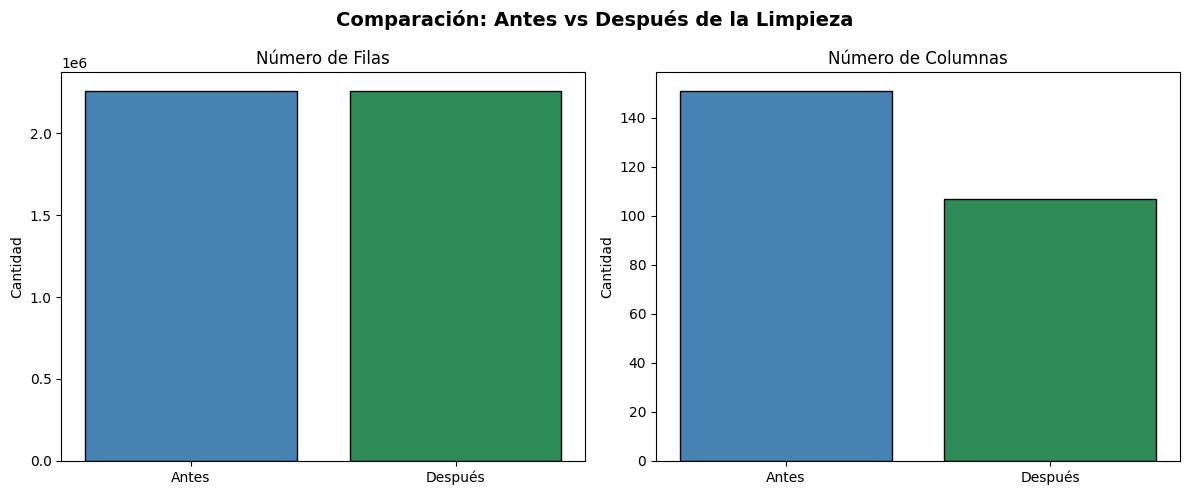


 Dataset limpio exportado como: 'lending_club_limpio.csv'
 Proceso completado.


In [ ]:
# PARTE 6: RESUMEN COMPARATIVO Y EXPORTACIÓN

print("=" * 60)
print("RESUMEN DE LA LIMPIEZA")
print("=" * 60)

resumen = pd.DataFrame({
    'Métrica': ['Filas', 'Columnas', 'Valores nulos', 'Duplicados'],
    'Antes': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ],
    'Después': [
        df_limpio.shape[0],
        df_limpio.shape[1],
        df_limpio.isnull().sum().sum(),
        df_limpio.duplicated().sum()
    ]
})
resumen['Diferencia'] = resumen['Antes'] - resumen['Después']
print(resumen.to_string(index=False))

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Antes', 'Después'], [df.shape[0], df_limpio.shape[0]],
            color=['steelblue', 'seagreen'], edgecolor='black')
axes[0].set_title('Número de Filas')
axes[0].set_ylabel('Cantidad')

axes[1].bar(['Antes', 'Después'], [df.shape[1], df_limpio.shape[1]],
            color=['steelblue', 'seagreen'], edgecolor='black')
axes[1].set_title('Número de Columnas')
axes[1].set_ylabel('Cantidad')

plt.suptitle('Comparación: Antes vs Después de la Limpieza', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Exportar
df_limpio.to_csv("lending_club_limpio.csv", index=False)
print("\n Dataset limpio exportado como: 'lending_club_limpio.csv'")
print(" Proceso completado.")

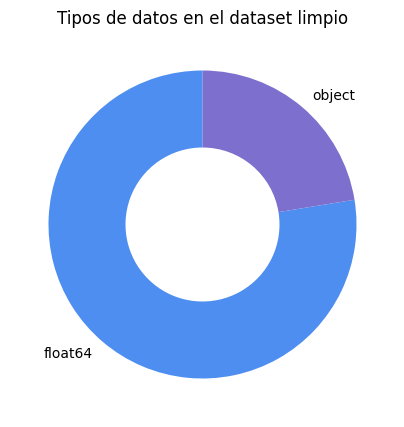

In [ ]:
conteo_tipos = df_limpio.dtypes.value_counts()
etiquetas = [str(t) for t in conteo_tipos.index]
valores   = conteo_tipos.values
colores   = ['#4d8ef0', '#7c6fcd', '#2db87e']

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(valores, labels=etiquetas, colors=colores[:len(valores)],
       wedgeprops=dict(width=0.5), startangle=90)
ax.set_title('Tipos de datos en el dataset limpio')
plt.savefig("grafica_tipos_datos.png")
plt.show()

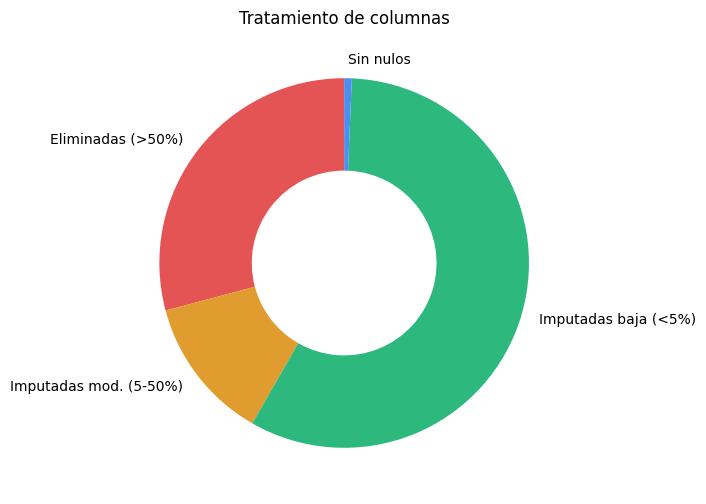

In [ ]:
import matplotlib.patches as mpatches

etiquetas = ['Eliminadas (>50%)', 'Imputadas mod. (5-50%)', 'Imputadas baja (<5%)', 'Sin nulos']
valores   = [len(col_alta), len(col_media), len(col_baja),
             df_limpio.shape[1] - len(col_media) - len(col_baja)]
colores   = ['#e55454', '#e09c2f', '#2db87e', '#4d8ef0']

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(valores, labels=etiquetas, colors=colores,
       wedgeprops=dict(width=0.5),
       startangle=90)
ax.set_title('Tratamiento de columnas')
plt.savefig("grafica_Tratamiento_de_columnas.png")
plt.show()

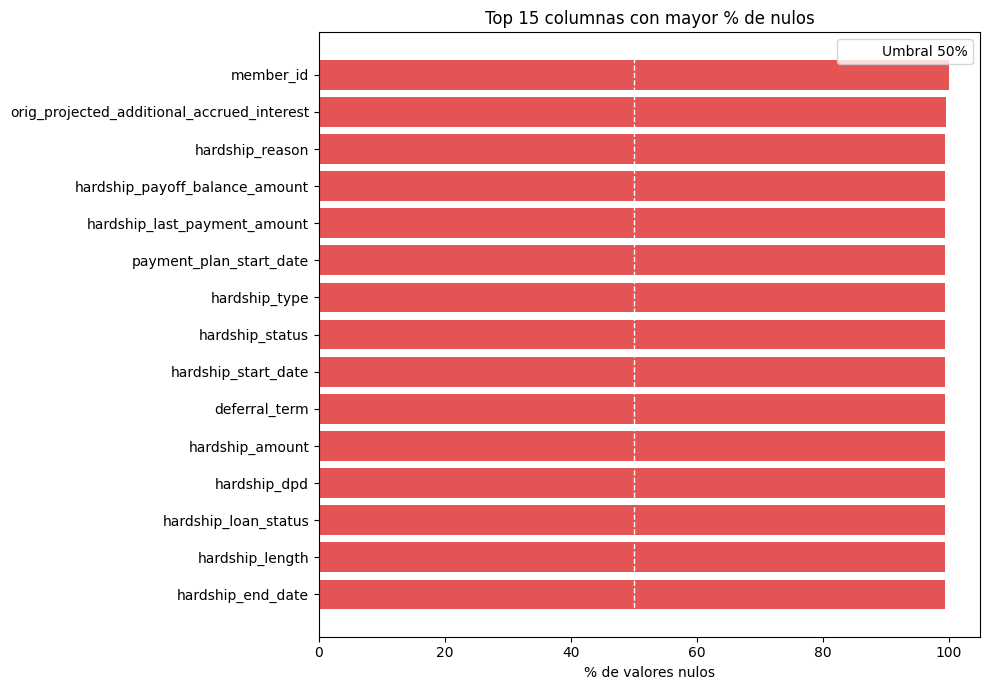

In [ ]:
top15 = resumen_nulos.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colores_barras = ['#e55454' if p > 50 else '#e09c2f'
                  for p in top15['Porcentaje (%)']]

ax.barh(top15.index[::-1], top15['Porcentaje (%)'][::-1],
        color=colores_barras[::-1])
ax.axvline(x=50, color='white', linestyle='--', linewidth=1, label='Umbral 50%')
ax.set_xlabel('% de valores nulos')
ax.set_title('Top 15 columnas con mayor % de nulos')
ax.legend()
plt.tight_layout()
plt.savefig("grafica_de_columnas_nulos.png")
plt.show()

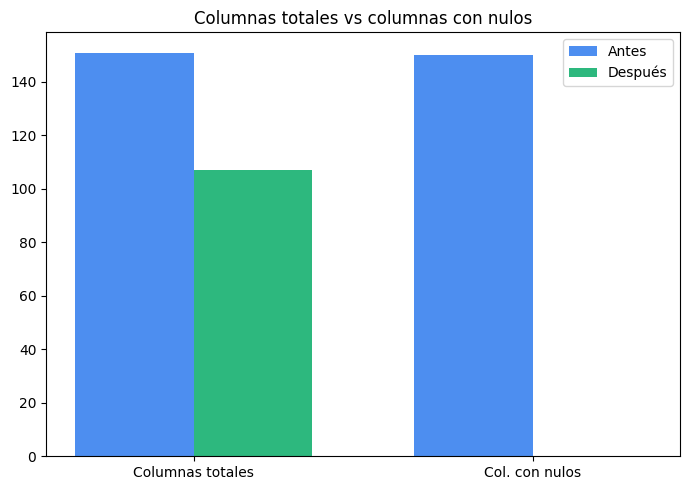

In [ ]:
categorias = ['Columnas totales', 'Col. con nulos']
antes   = [df.shape[1], df.isnull().any().sum()]
despues = [df_limpio.shape[1], df_limpio.isnull().any().sum()]  # → 0

x = np.arange(len(categorias))
ancho = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - ancho/2, antes,   ancho, label='Antes',   color='#4d8ef0')
ax.bar(x + ancho/2, despues, ancho, label='Después', color='#2db87e')
ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.set_title('Columnas totales vs columnas con nulos')
ax.legend()
plt.tight_layout()
plt.savefig("grafica_de_columnas_nulos_totales.png")
plt.show()

In [ ]:
#Autores: Gabriel David Torres Montiel
         #Jose Angel Gomez Agamez

In [ ]:
#dashboard: https://gabrieltorres09.github.io/Proyecto_corte3/

In [ ]:
traduccion_columnas = {
    # ── Información básica del préstamo ──────────────────────
    'id'                        : 'id_prestamo',
    'member_id'                 : 'id_miembro',
    'loan_amnt'                 : 'monto_solicitado',
    'funded_amnt'               : 'monto_financiado',
    'funded_amnt_inv'           : 'monto_financiado_inversores',
    'term'                      : 'plazo',
    'int_rate'                  : 'tasa_interes',
    'installment'               : 'cuota_mensual',
    'grade'                     : 'calificacion',
    'sub_grade'                 : 'subcalificacion',
    'loan_status'               : 'estado_prestamo',
    'pymnt_plan'                : 'plan_de_pago',
    'purpose'                   : 'proposito',
    'title'                     : 'titulo_prestamo',
    'url'                       : 'url_prestamo',
    'desc'                      : 'descripcion',
    'issue_d'                   : 'fecha_emision',
    'initial_list_status'       : 'estado_inicial_lista',
    'application_type'          : 'tipo_solicitud',

    # ── Información del solicitante ───────────────────────────
    'emp_title'                 : 'titulo_empleo',
    'emp_length'                : 'antiguedad_laboral',
    'home_ownership'            : 'tipo_vivienda',
    'annual_inc'                : 'ingreso_anual',
    'verification_status'       : 'estado_verificacion',
    'zip_code'                  : 'codigo_postal',
    'addr_state'                : 'estado_residencia',
    'dti'                       : 'relacion_deuda_ingreso',
    'earliest_cr_line'          : 'primera_linea_credito',
    'annual_inc_joint'          : 'ingreso_anual_conjunto',
    'dti_joint'                 : 'relacion_deuda_ingreso_conjunto',
    'verification_status_joint' : 'verificacion_conjunta',

    # ── Historial de pagos y mora ─────────────────────────────
    'delinq_2yrs'               : 'moras_ultimos_2_anios',
    'inq_last_6mths'            : 'consultas_ultimos_6_meses',
    'mths_since_last_delinq'    : 'meses_desde_ultima_mora',
    'mths_since_last_record'    : 'meses_desde_ultimo_registro',
    'open_acc'                  : 'cuentas_abiertas',
    'pub_rec'                   : 'registros_publicos_negativos',
    'revol_bal'                 : 'saldo_rotativo',
    'revol_util'                : 'uso_credito_rotativo',
    'total_acc'                 : 'total_cuentas_credito',
    'out_prncp'                 : 'capital_pendiente',
    'out_prncp_inv'             : 'capital_pendiente_inversores',
    'total_pymnt'               : 'total_pagado',
    'total_pymnt_inv'           : 'total_pagado_inversores',
    'total_rec_prncp'           : 'capital_recuperado',
    'total_rec_int'             : 'intereses_recuperados',
    'total_rec_late_fee'        : 'cargos_mora_recuperados',
    'recoveries'                : 'recuperaciones',
    'collection_recovery_fee'   : 'comision_recuperacion',
    'last_pymnt_d'              : 'fecha_ultimo_pago',
    'last_pymnt_amnt'           : 'monto_ultimo_pago',
    'next_pymnt_d'              : 'fecha_proximo_pago',
    'last_credit_pull_d'        : 'ultima_consulta_credito',
    'collections_12_mths_ex_med': 'cobros_12_meses',
    'mths_since_last_major_derog':'meses_desde_derogacion_mayor',
    'acc_now_delinq'            : 'cuentas_en_mora_actual',
    'tot_coll_amt'              : 'total_cobros',
    'tot_cur_bal'               : 'saldo_actual_total',
    'open_acc_6m'               : 'cuentas_abiertas_6_meses',
    'open_il_6m'                : 'cuentas_a_plazo_abiertas_6m',
    'open_il_12m'               : 'cuentas_a_plazo_abiertas_12m',
    'open_il_24m'               : 'cuentas_a_plazo_abiertas_24m',
    'mths_since_rcnt_il'        : 'meses_desde_cuenta_a_plazo',
    'total_bal_il'              : 'saldo_total_plazo',
    'il_util'                   : 'uso_credito_plazo',
    'open_rv_12m'               : 'cuentas_rotativas_12_meses',
    'open_rv_24m'               : 'cuentas_rotativas_24_meses',
    'max_bal_bc'                : 'saldo_maximo_tarjeta',
    'all_util'                  : 'uso_total_credito',
    'total_rev_hi_lim'          : 'limite_total_rotativo',
    'inq_fi'                    : 'consultas_prestamos_personales',
    'total_cu_tl'               : 'cuentas_credito_union',
    'inq_last_12m'              : 'consultas_ultimos_12_meses',

    # ── Puntaje FICO (score crediticio) ───────────────────────
    'fico_range_low'            : 'fico_minimo',
    'fico_range_high'           : 'fico_maximo',
    'last_fico_range_high'      : 'ultimo_fico_maximo',
    'last_fico_range_low'       : 'ultimo_fico_minimo',

    # ── Política y otros ──────────────────────────────────────
    'policy_code'               : 'codigo_politica',
    'hardship_flag'             : 'flag_dificultad',
    'disbursement_method'       : 'metodo_desembolso',
    'debt_settlement_flag'      : 'flag_acuerdo_deuda',
    'chargeoff_within_12_mths'  : 'cancelaciones_12_meses',
    'delinq_amnt'               : 'monto_en_mora',
    'num_tl_op_past_12m'        : 'cuentas_activas_12_meses',
    'num_actv_bc_tl'            : 'tarjetas_activas',
    'num_actv_rev_tl'           : 'cuentas_rotativas_activas',
    'num_bc_sats'               : 'tarjetas_al_dia',
    'num_bc_tl'                 : 'total_tarjetas',
    'num_il_tl'                 : 'total_prestamos_plazo',
    'num_op_rev_tl'             : 'cuentas_rotativas_abiertas',
    'num_rev_accts'             : 'total_cuentas_rotativas',
    'num_rev_tl_bal_gt_0'       : 'cuentas_rotativas_con_saldo',
    'num_sats'                  : 'cuentas_satisfactorias',
    'num_tl_120dpd_2m'          : 'cuentas_120_dias_mora',
    'num_tl_30dpd'              : 'cuentas_30_dias_mora',
    'num_tl_90g_dpd_24m'        : 'cuentas_90_dias_mora_24m',
    'pct_tl_nvr_dlq'            : 'porcentaje_sin_mora',
    'percent_bc_gt_75'          : 'tarjetas_uso_mayor_75',
    'pub_rec_bankruptcies'      : 'quiebras_registradas',
    'tax_liens'                 : 'gravamenes_fiscales',
    'tot_hi_cred_lim'           : 'limite_credito_total',
    'total_bal_ex_mort'         : 'saldo_total_sin_hipoteca',
    'total_bc_limit'            : 'limite_total_tarjetas',
    'total_il_high_credit_limit': 'limite_credito_prestamos_plazo',
}


# ─────────────────────────────────────────────────────────────
# PASO 2: RENOMBRAR SOLO LAS COLUMNAS QUE EXISTEN EN df_limpio
# (evita errores si algunas columnas ya fueron eliminadas)
# ─────────────────────────────────────────────────────────────

df_es = df_limpio.copy()

# Filtrar solo las columnas que realmente están en el DataFrame
traduccion_valida = {k: v for k, v in traduccion_columnas.items()
                     if k in df_es.columns}

df_es.rename(columns=traduccion_valida, inplace=True)

print("=" * 60)
print("DATASET CON COLUMNAS EN ESPAÑOL")
print("=" * 60)
print(f"\nColumnas traducidas : {len(traduccion_valida)}")
print(f"Columnas totales    : {df_es.shape[1]}")
print(f"Filas               : {df_es.shape[0]:,}")
print("\nPrimeras columnas del dataset traducido:")
print(list(df_es.columns[:15]))


# ─────────────────────────────────────────────────────────────
# PASO 3: ESTADÍSTICAS CLAVE DEL PRÉSTAMO
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("ESTADÍSTICAS GENERALES DE LOS PRÉSTAMOS")
print("=" * 60)

col_monto = 'monto_solicitado' if 'monto_solicitado' in df_es.columns else None

if col_monto:
    prestamo_max    = df_es[col_monto].max()
    prestamo_min    = df_es[col_monto].min()
    prestamo_prom   = df_es[col_monto].mean()
    prestamo_median = df_es[col_monto].median()
    prestamo_total  = df_es[col_monto].sum()

    print(f"\n  Préstamo más grande  : ${prestamo_max:>12,.0f}")
    print(f"  Préstamo más pequeño : ${prestamo_min:>12,.0f}")
    print(f"  Préstamo promedio    : ${prestamo_prom:>12,.0f}")
    print(f"  Préstamo mediano     : ${prestamo_median:>12,.0f}")
    print(f"  Total prestado       : ${prestamo_total:>12,.0f}")

# Tasa de interés
if 'tasa_interes' in df_es.columns:
    df_es['tasa_interes_num'] = pd.to_numeric(
        df_es['tasa_interes'].astype(str).str.replace('%', ''), errors='coerce')
    print(f"\n  Tasa de interés mínima  : {df_es['tasa_interes_num'].min():.2f}%")
    print(f"  Tasa de interés máxima  : {df_es['tasa_interes_num'].max():.2f}%")
    print(f"  Tasa de interés promedio: {df_es['tasa_interes_num'].mean():.2f}%")

# Ingreso anual
if 'ingreso_anual' in df_es.columns:
    print(f"\n  Ingreso anual mínimo  : ${df_es['ingreso_anual'].min():>12,.0f}")
    print(f"  Ingreso anual máximo  : ${df_es['ingreso_anual'].max():>12,.0f}")
    print(f"  Ingreso anual promedio: ${df_es['ingreso_anual'].mean():>12,.0f}")


# ─────────────────────────────────────────────────────────────
# PASO 4: ANÁLISIS POR CATEGORÍAS
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("DISTRIBUCIONES POR CATEGORÍA")
print("=" * 60)

# Estado del préstamo
if 'estado_prestamo' in df_es.columns:
    print("\n--- Estado del préstamo ---")
    conteo = df_es['estado_prestamo'].value_counts()
    pct    = (conteo / len(df_es) * 100).round(2)
    resumen_estado = pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': pct})
    print(resumen_estado.to_string())

# Propósito del préstamo
if 'proposito' in df_es.columns:
    print("\n--- Propósito del préstamo ---")
    print(df_es['proposito'].value_counts().head(10).to_string())

# Calificación
if 'calificacion' in df_es.columns:
    print("\n--- Calificación del préstamo (A = menor riesgo, G = mayor riesgo) ---")
    print(df_es['calificacion'].value_counts().sort_index().to_string())

# Plazo
if 'plazo' in df_es.columns:
    print("\n--- Plazo del préstamo ---")
    print(df_es['plazo'].value_counts().to_string())


# ─────────────────────────────────────────────────────────────
# PASO 5: GRÁFICOS EN ESPAÑOL
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Lending Club — Análisis General de Préstamos', fontsize=16, fontweight='bold')

colores_base = ['#4d8ef0', '#2db87e', '#e09c2f', '#e55454',
                '#9b59b6', '#1abc9c', '#e67e22']

# ── Gráfico 1: Distribución de montos solicitados ────────────
ax = axes[0, 0]
if col_monto:
    ax.hist(df_es[col_monto].dropna(), bins=40, color='#4d8ef0',
            edgecolor='white', linewidth=0.5)
    ax.set_title('Distribución de Montos Solicitados')
    ax.set_xlabel('Monto (USD)')
    ax.set_ylabel('Número de préstamos')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# ── Gráfico 2: Estado del préstamo ───────────────────────────
ax = axes[0, 1]
if 'estado_prestamo' in df_es.columns:
    datos = df_es['estado_prestamo'].value_counts().head(6)
    bars = ax.barh(datos.index, datos.values,
                   color=colores_base[:len(datos)], edgecolor='white')
    ax.set_title('Estado del Préstamo')
    ax.set_xlabel('Cantidad de préstamos')
    for bar in bars:
        ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
                f'{bar.get_width():,.0f}', va='center', fontsize=8)

# ── Gráfico 3: Propósito del préstamo ────────────────────────
ax = axes[1, 0]
if 'proposito' in df_es.columns:
    datos = df_es['proposito'].value_counts().head(8)
    ax.bar(datos.index, datos.values,
           color=colores_base[:len(datos)], edgecolor='white')
    ax.set_title('Propósito del Préstamo (Top 8)')
    ax.set_ylabel('Cantidad')
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)

# ── Gráfico 4: Calificación del préstamo ─────────────────────
ax = axes[1, 1]
if 'calificacion' in df_es.columns:
    datos = df_es['calificacion'].value_counts().sort_index()
    colores_grade = ['#2db87e','#4d8ef0','#7c6fcd','#e09c2f','#e07a2f','#e55454','#8b0000']
    ax.bar(datos.index, datos.values,
           color=colores_grade[:len(datos)], edgecolor='white')
    ax.set_title('Calificación del Préstamo\n(A = menor riesgo → G = mayor riesgo)')
    ax.set_ylabel('Cantidad de préstamos')

plt.tight_layout()
plt.savefig('lending_club_analisis_espanol.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Gráfico guardado como: 'lending_club_analisis_espanol.png'")


# ─────────────────────────────────────────────────────────────
# PASO 6: EXPORTAR DATASET TRADUCIDO
# ─────────────────────────────────────────────────────────────

df_es.to_csv('lending_club_espanol.csv', index=False)
print(" Dataset en español exportado como: 'lending_club_espanol.csv'")

print("\n" + "=" * 60)
print("TABLA: COLUMNAS ORIGINALES → ESPAÑOL")
print("=" * 60)
tabla_traduccion = pd.DataFrame({
    'Columna original (inglés)': list(traduccion_valida.keys()),
    'Columna traducida (español)': list(traduccion_valida.values())
})
print(tabla_traduccion.to_string(index=False))
